# 18. Final model evaluation and comparison

This notebook performs the final analyses requested after model development:

- threshold-independent test metrics: AUPRC, AUROC, Brier score;
- selected final hyperparameters for all six models, saved as CSV and JSON;
- performance at validation-selected 70%, 75%, 80%, 85%, and 90% recall targets;
- the primary 80% operating-point comparison;
- paired bootstrap uncertainty and pairwise model differences;
- calibration curves plus calibration intercept and slope;
- saved tables and figures for the thesis.

No models are trained or retuned here.


In [1]:

from pathlib import Path
from itertools import combinations
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Bootstrap settings control the resampling uncertainty analysis; the primary operating point remains 80% recall.
BOOTSTRAP_REPEATS = 2000
BOOTSTRAP_SEED = 20260823
PRIMARY_RECALL_TARGET = 0.80
CALIBRATION_BINS = 10

# This notebook reads only frozen predictions and saved artifacts; it does not fit any predictive model.
PROJECT_ROOT = Path.cwd()
for parent in [PROJECT_ROOT] + list(PROJECT_ROOT.parents):
    candidate = parent / "Final_Evaluation" / "Results" / "final_test_predictions.csv"
    if candidate.exists():
        PROJECT_ROOT = parent
        PREDICTION_PATH = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find Final_Evaluation/Results/final_test_predictions.csv. "
        "Run notebook 17 first."
    )

FINAL_EVALUATION_DIR = PROJECT_ROOT / "Final_Evaluation"
ARTIFACT_ROOT = FINAL_EVALUATION_DIR / "Model_Artifacts"
RESULTS_DIR = FINAL_EVALUATION_DIR / "Results"
FIGURE_DIR = RESULTS_DIR / "Figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Each row contains the same patient outcome plus one probability from each model.
predictions = pd.read_csv(PREDICTION_PATH)

MODEL_COLUMNS = {
    "Regularised Logistic Regression": "logistic_regression",
    "Decision Tree": "decision_tree",
    "Random Forest": "random_forest",
    "XGBoost": "xgboost",
    "CatBoost": "catboost",
    "FT-Transformer": "ft_transformer",
}

y_true = predictions["y_true"].to_numpy(dtype=int)

print("Final test rows:", len(predictions))
print("Readmissions:", int(y_true.sum()))
print("Readmission prevalence:", float(y_true.mean()))


Final test rows: 13998
Readmissions: 1257
Readmission prevalence: 0.08979854264894985


## Load the validation-selected thresholds

In [2]:
# Load the validation-selected thresholds saved by notebooks 11–16.
# These thresholds are applied unchanged to the final-test probabilities.

artifact_slugs = {
    "Regularised Logistic Regression": "logistic_regression",
    "Decision Tree": "decision_tree",
    "Random Forest": "random_forest",
    "XGBoost": "xgboost",
    "CatBoost": "catboost",
    "FT-Transformer": "ft_transformer",
}

threshold_frames = []

for model_name, slug in artifact_slugs.items():
    path = ARTIFACT_ROOT / slug / "selected_validation_thresholds.csv"

    if not path.exists():
        raise FileNotFoundError(f"Missing threshold file: {path}")

    frame = pd.read_csv(path)
    frame["model"] = model_name
    threshold_frames.append(frame)

# Combine every model's 70%, 75%, 80%, 85% and 90% recall operating points into one table.
threshold_table = pd.concat(threshold_frames, ignore_index=True)

threshold_table[
    ["model", "target_recall", "selected_threshold",
     "validation_recall", "validation_false_positive_rate"]
].sort_values(["model", "target_recall"])


,model,target_recall,selected_threshold,validation_recall,validation_false_positive_rate
20,CatBoost,0.70,0.079774,0.700080,0.511734
21,CatBoost,0.75,0.075865,0.750199,0.578448
22,CatBoost,0.80,0.073206,0.800318,0.641708
23,CatBoost,0.85,0.070478,0.850438,0.717448
24,CatBoost,0.90,0.067541,0.900557,0.797504
5,Decision Tree,0.70,0.254665,0.700875,0.533632
6,Decision Tree,0.75,0.247582,0.753381,0.620516
7,Decision Tree,0.80,0.215385,0.801114,0.692803
8,Decision Tree,0.85,0.194175,0.861575,0.776077
9,Decision Tree,0.90,0.163855,0.900557,0.837925


## Final selected hyperparameters

This section reads the frozen model-selection artifacts produced by notebooks 11–16. It does not retune any model. The selected settings are consolidated into one long-format table for display and saved to the final results folder as both CSV and JSON.


In [3]:
def _display_value(value):
    """Convert nested/list hyperparameter values into readable table strings."""
    if isinstance(value, (dict, list, tuple)):
        return json.dumps(value, sort_keys=True)
    if value is None:
        return "None"
    return str(value)


def _append_parameter_rows(rows, model, group, parameters):
    """Flatten one hyperparameter group into rows for the final long-format table."""
    for parameter, value in parameters.items():
        rows.append({
            "model": model,
            "parameter_group": group,
            "parameter": parameter,
            "value": _display_value(value),
        })


# Read, rather than recompute, the already-selected settings for all six models.
selected_hyperparameters = {}

# Regularised Logistic Regression
lr_dir = ARTIFACT_ROOT / "logistic_regression"
with open(lr_dir / "selected_hyperparameters.json") as f:
    lr_saved = json.load(f)

lr_variant = lr_saved["variant"]
lr_key = f"{lr_variant}_best_params"
if lr_key not in lr_saved:
    raise KeyError(
        f"Could not find {lr_key!r} in Logistic Regression hyperparameter artifact."
    )

selected_hyperparameters["Regularised Logistic Regression"] = {
    "variant": lr_variant,
    "model": lr_saved[lr_key],
}

# Decision Tree
with open(
    ARTIFACT_ROOT / "decision_tree" / "selected_hyperparameters.json"
) as f:
    dt_saved = json.load(f)

selected_hyperparameters["Decision Tree"] = {
    "model": dt_saved,
}

# Random Forest
with open(
    ARTIFACT_ROOT / "random_forest" / "selected_hyperparameters.json"
) as f:
    rf_saved = json.load(f)

selected_hyperparameters["Random Forest"] = {
    "model": rf_saved,
}

# XGBoost
with open(
    ARTIFACT_ROOT / "xgboost" / "selected_hyperparameters.json"
) as f:
    xgb_saved = json.load(f)

selected_hyperparameters["XGBoost"] = {
    "structure": xgb_saved["structure"],
    "training": {
        "learning_rate": xgb_saved["learning_rate"],
        "n_estimators": xgb_saved["n_estimators"],
    },
}

# CatBoost
with open(
    ARTIFACT_ROOT / "catboost" / "selected_hyperparameters.json"
) as f:
    cat_saved = json.load(f)

selected_hyperparameters["CatBoost"] = {
    "structure": cat_saved["structure"],
    "training": {
        "learning_rate": cat_saved["learning_rate"],
        "iterations": cat_saved["iterations"],
    },
}

# FT-Transformer
ftt_dir = ARTIFACT_ROOT / "ft_transformer"

with open(ftt_dir / "selected_architecture.json") as f:
    ftt_architecture = json.load(f)

with open(ftt_dir / "selected_training_config.json") as f:
    ftt_training = json.load(f)

selected_hyperparameters["FT-Transformer"] = {
    "architecture": ftt_architecture,
    "training": ftt_training,
}


# Different model families save parameters in different structures, so flatten them into one consistent schema.
# Build a readable long-format table.
hyperparameter_rows = []

for model_name, groups in selected_hyperparameters.items():
    for group_name, values in groups.items():
        if isinstance(values, dict):
            _append_parameter_rows(
                hyperparameter_rows,
                model=model_name,
                group=group_name,
                parameters=values,
            )
        else:
            hyperparameter_rows.append({
                "model": model_name,
                "parameter_group": "selection",
                "parameter": group_name,
                "value": _display_value(values),
            })

selected_hyperparameters_table = (
    pd.DataFrame(hyperparameter_rows)
    .sort_values(
        ["model", "parameter_group", "parameter"]
    )
    .reset_index(drop=True)
)

# Save both a human-readable table and the original nested structure.
selected_hyperparameters_table.to_csv(
    RESULTS_DIR / "final_selected_hyperparameters.csv",
    index=False,
)

with open(
    RESULTS_DIR / "final_selected_hyperparameters.json",
    "w",
) as f:
    json.dump(
        selected_hyperparameters,
        f,
        indent=2,
        default=str,
    )

print(
    "Saved:",
    RESULTS_DIR / "final_selected_hyperparameters.csv",
)
print(
    "Saved:",
    RESULTS_DIR / "final_selected_hyperparameters.json",
)

selected_hyperparameters_table


Saved: /Users/xiaohanmu/Desktop/School/UoB/Summer Individual Project/Processing_Pipeline/Pipeline_Selection/Final_Evaluation/Results/final_selected_hyperparameters.csv
Saved: /Users/xiaohanmu/Desktop/School/UoB/Summer Individual Project/Processing_Pipeline/Pipeline_Selection/Final_Evaluation/Results/final_selected_hyperparameters.json


,model,parameter_group,parameter,value
0,CatBoost,structure,border_count,64
1,CatBoost,structure,depth,5
2,CatBoost,structure,l2_leaf_reg,10.0
3,CatBoost,structure,max_ctr_complexity,1
4,CatBoost,structure,random_strength,2.0
5,CatBoost,structure,scale_pos_weight,1.0
6,CatBoost,structure,subsample,1.0
7,CatBoost,training,iterations,172
8,CatBoost,training,learning_rate,0.03
9,Decision Tree,model,model__ccp_alpha,5e-05


## Threshold-independent discrimination and probability-quality metrics

In [4]:
# AUPRC and AUROC evaluate ranking/discrimination without a classification threshold.
# Brier score evaluates the quality of the raw predicted probabilities.

threshold_independent_rows = []

# Compute all three metrics from exactly the same locked test patients.
for model_name, column in MODEL_COLUMNS.items():
    probability = predictions[column].to_numpy(dtype=float)

    threshold_independent_rows.append({
        "model": model_name,
        "auprc": average_precision_score(y_true, probability),
        "auroc": roc_auc_score(y_true, probability),
        "brier_score": brier_score_loss(y_true, probability),
    })

threshold_independent_metrics = (
    pd.DataFrame(threshold_independent_rows)
    .sort_values("auprc", ascending=False)
    .reset_index(drop=True)
)

threshold_independent_metrics.to_csv(
    RESULTS_DIR / "final_threshold_independent_metrics.csv",
    index=False,
)

threshold_independent_metrics


,model,auprc,auroc,brier_score
0,FT-Transformer,0.159364,0.650099,0.085021
1,Random Forest,0.158708,0.650656,0.079931
2,XGBoost,0.155798,0.649223,0.153474
3,CatBoost,0.154663,0.644708,0.080009
4,Regularised Logistic Regression,0.154082,0.649109,0.235378
5,Decision Tree,0.137390,0.618418,0.118492


## Apply all validation-selected recall thresholds to the final test set

In [5]:

def operating_point_metrics(y_true, probability, threshold):
    """Evaluate one frozen probability threshold on the final test set.

    Recall measures how many readmissions are found; specificity measures how many
    non-readmitted patients are correctly left unflagged; FPR is 1 - specificity.
    """
    # Convert continuous risk into the binary flag produced at this operating point.
    y_pred = (probability >= threshold).astype(int)

    # Extract the four outcome counts used for recall, precision, specificity and workload.
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    recall = recall_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)

    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    fpr = fp / (tn + fp) if (tn + fp) else np.nan
    flagged_rate = (tp + fp) / len(y_true)

    return {
        "test_recall": recall,
        "test_precision": precision,
        "test_specificity": specificity,
        "test_false_positive_rate": fpr,
        "test_f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "true_positive": int(tp),
        "false_negative": int(fn),
        "false_positive": int(fp),
        "true_negative": int(tn),
        "flagged_count": int(tp + fp),
        "flagged_rate": flagged_rate,
    }


# Evaluate every model at every threshold that was selected earlier on validation data.
operating_rows = []

for model_name, column in MODEL_COLUMNS.items():
    probability = predictions[column].to_numpy(dtype=float)

    model_thresholds = threshold_table[
        threshold_table["model"] == model_name
    ].sort_values("target_recall")

    # Each row corresponds to one target-recall level such as 70%, 80% or 90%.
    for _, threshold_row in model_thresholds.iterrows():
        threshold = float(threshold_row["selected_threshold"])
        metrics = operating_point_metrics(
            y_true=y_true,
            probability=probability,
            threshold=threshold,
        )

        operating_rows.append({
            "model": model_name,
            "target_recall": float(threshold_row["target_recall"]),
            "selected_validation_threshold": threshold,
            "validation_recall": float(threshold_row["validation_recall"]),
            **metrics,
        })

operating_results = pd.DataFrame(operating_rows)

operating_results.to_csv(
    RESULTS_DIR / "final_recall_threshold_sensitivity.csv",
    index=False,
)

operating_results.sort_values(
    ["target_recall", "test_false_positive_rate", "model"]
)


,model,target_recall,selected_validation_threshold,validation_recall,test_recall,test_precision,test_specificity,test_false_positive_rate,test_f2,true_positive,false_negative,false_positive,true_negative,flagged_count,flagged_rate
25,FT-Transformer,0.70,0.162097,0.700080,0.701671,0.122144,0.502472,0.497528,0.360029,882,375,6339,6402,7221,0.515859
0,Regularised Logistic Regression,0.70,0.451233,0.700080,0.702466,0.121928,0.500903,0.499097,0.359821,883,374,6359,6382,7242,0.517360
10,Random Forest,0.70,0.080085,0.700080,0.707239,0.122368,0.499568,0.500432,0.361588,889,368,6376,6365,7265,0.519003
15,XGBoost,0.70,0.330388,0.700080,0.715990,0.123372,0.498077,0.501923,0.365171,900,357,6395,6346,7295,0.521146
20,CatBoost,0.70,0.079774,0.700080,0.694511,0.119918,0.497135,0.502865,0.354647,873,384,6407,6334,7280,0.520074
5,Decision Tree,0.70,0.254665,0.700875,0.700875,0.116288,0.474531,0.525469,0.349492,881,376,6695,6046,7576,0.541220
26,FT-Transformer,0.75,0.151229,0.750199,0.750994,0.116933,0.440468,0.559532,0.360278,944,313,7129,5612,8073,0.576725
16,XGBoost,0.75,0.315548,0.750199,0.765314,0.118356,0.437564,0.562436,0.365613,962,295,7166,5575,8128,0.580654
11,Random Forest,0.75,0.075958,0.750199,0.757359,0.117140,0.436857,0.563143,0.361840,952,305,7175,5566,8127,0.580583
1,Regularised Logistic Regression,0.75,0.435712,0.750199,0.760541,0.116713,0.432148,0.567852,0.361601,956,301,7235,5506,8191,0.585155


## Primary 80% recall-target comparison

In [6]:
# The project's main operating comparison is the validation-selected 80% recall target.

primary_operating_results = (
    operating_results[
        np.isclose(
            operating_results["target_recall"],
            PRIMARY_RECALL_TARGET,
        )
    ]
    .merge(
        threshold_independent_metrics,
        on="model",
        how="left",
    )
    .sort_values(
        ["test_false_positive_rate", "auprc"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

primary_columns = [
    "model",
    "selected_validation_threshold",
    "auprc",
    "auroc",
    "brier_score",
    "validation_recall",
    "test_recall",
    "test_precision",
    "test_specificity",
    "test_false_positive_rate",
    "test_f2",
    "true_positive",
    "false_negative",
    "false_positive",
    "true_negative",
    "flagged_count",
    "flagged_rate",
]

primary_operating_results = primary_operating_results[primary_columns]

primary_operating_results.to_csv(
    RESULTS_DIR / "final_primary_80_recall_comparison.csv",
    index=False,
)

primary_operating_results


,model,selected_validation_threshold,auprc,auroc,brier_score,validation_recall,test_recall,test_precision,test_specificity,test_false_positive_rate,test_f2,true_positive,false_negative,false_positive,true_negative,flagged_count,flagged_rate
0,XGBoost,0.302097,0.155798,0.649223,0.153474,0.800318,0.797932,0.112633,0.379798,0.620202,0.359937,1003,254,7902,4839,8905,0.636162
1,Random Forest,0.072620,0.158708,0.650656,0.079931,0.800318,0.807478,0.112665,0.372577,0.627423,0.361544,1015,242,7994,4747,9009,0.643592
2,CatBoost,0.073206,0.154663,0.644708,0.080009,0.800318,0.800318,0.111222,0.369045,0.630955,0.357422,1006,251,8039,4702,9045,0.646164
3,FT-Transformer,0.138604,0.159364,0.650099,0.085021,0.800318,0.816229,0.112475,0.364571,0.635429,0.362544,1026,231,8096,4645,9122,0.651665
4,Regularised Logistic Regression,0.422583,0.154082,0.649109,0.235378,0.800318,0.811456,0.111646,0.363001,0.636999,0.360068,1020,237,8116,4625,9136,0.652665
5,Decision Tree,0.215385,0.137390,0.618418,0.118492,0.801114,0.813842,0.104356,0.310886,0.689114,0.344886,1023,234,8780,3961,9803,0.700314


## Recall-target sensitivity figure

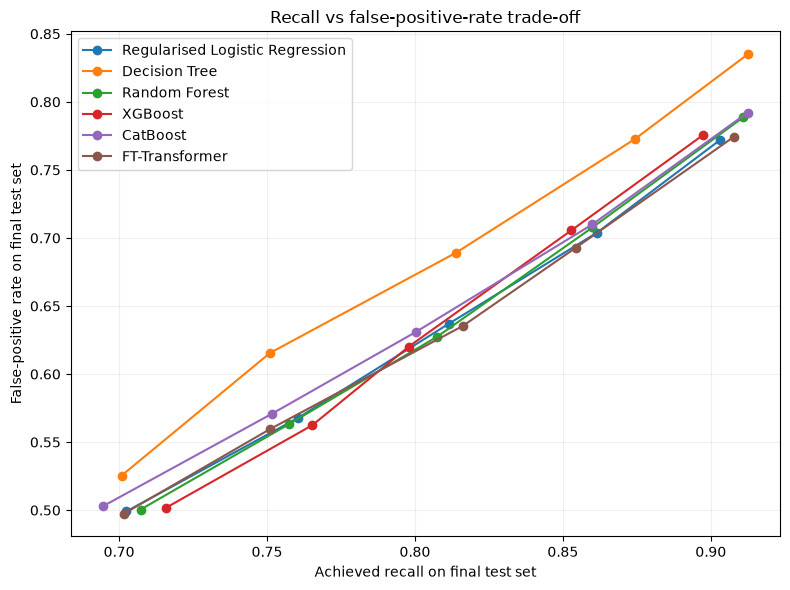

Saved: /Users/xiaohanmu/Desktop/School/UoB/Summer Individual Project/Processing_Pipeline/Pipeline_Selection/Final_Evaluation/Results/Figures/recall_fpr_tradeoff.png


In [7]:
# Plot achieved test recall against test FPR across the saved 70–90% target-recall range.

plt.figure(figsize=(8, 6))

for model_name in MODEL_COLUMNS:
    subset = (
        operating_results[operating_results["model"] == model_name]
        .sort_values("target_recall")
    )

    plt.plot(
        subset["test_recall"],
        subset["test_false_positive_rate"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Achieved recall on final test set")
plt.ylabel("False-positive rate on final test set")
plt.title("Recall vs false-positive-rate trade-off")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

threshold_tradeoff_path = FIGURE_DIR / "recall_fpr_tradeoff.png"
plt.savefig(threshold_tradeoff_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", threshold_tradeoff_path)


## Calibration

The curve compares predicted probability with observed readmission frequency.

Calibration intercept and slope are estimated by fitting:

`logit(observed outcome) ~ intercept + slope × logit(predicted probability)`

Ideal values are approximately intercept = 0 and slope = 1.

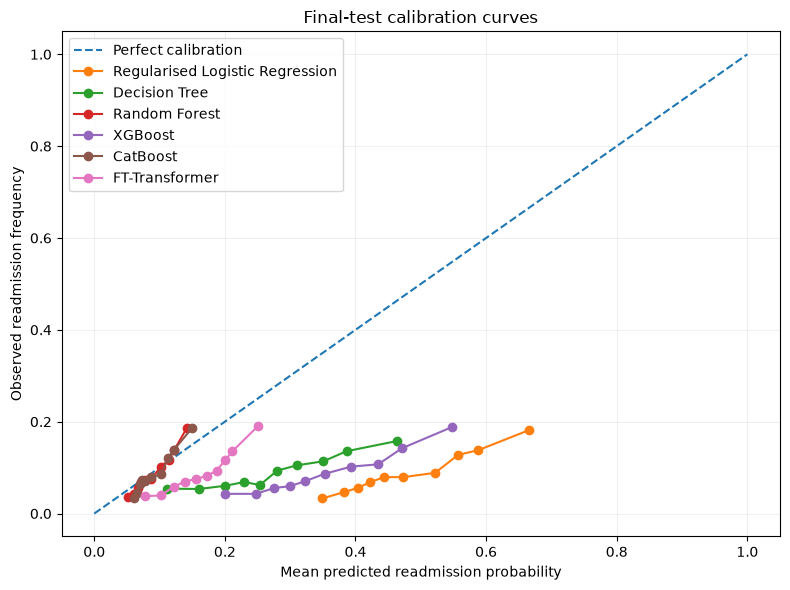

,model,brier_score,calibration_intercept,calibration_slope
0,Regularised Logistic Regression,0.235378,-2.323995,1.122496
1,Decision Tree,0.118492,-1.588686,0.757878
2,Random Forest,0.079931,1.263706,1.563432
3,XGBoost,0.153474,-1.732931,1.106941
4,CatBoost,0.080009,1.061937,1.490742
5,FT-Transformer,0.085021,-0.096214,1.378141


In [8]:

def calibration_intercept_slope(y, probability, max_iter=100, tolerance=1e-10):
    """Estimate calibration intercept and slope with Newton-Raphson.

    Ideal calibration has intercept near 0 and slope near 1.
    Intercept captures systematic probability bias; slope captures probabilities
    that are too extreme or too compressed.
    """
    y = np.asarray(y, dtype=float)
    # Avoid exact 0/1 values because their logit would be infinite.
    p = np.clip(np.asarray(probability, dtype=float), 1e-6, 1 - 1e-6)
    logit_p = np.log(p / (1 - p))

    X_design = np.column_stack([
        np.ones_like(logit_p),
        logit_p,
    ])

    beta = np.array([0.0, 1.0], dtype=float)

    # Newton-Raphson repeatedly updates the two calibration coefficients until convergence.
    for _ in range(max_iter):
        eta = X_design @ beta
        mu = 1.0 / (1.0 + np.exp(-np.clip(eta, -35, 35)))

        weights = np.clip(mu * (1 - mu), 1e-10, None)
        gradient = X_design.T @ (y - mu)
        hessian = -(X_design.T @ (weights[:, None] * X_design))

        step = np.linalg.solve(hessian, gradient)
        new_beta = beta - step

        if np.max(np.abs(new_beta - beta)) < tolerance:
            beta = new_beta
            break

        beta = new_beta

    return float(beta[0]), float(beta[1])


calibration_rows = []

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

for model_name, column in MODEL_COLUMNS.items():
    probability = predictions[column].to_numpy(dtype=float)

    # Quantile bins contain roughly similar numbers of patients, improving stability for rare outcomes.
    observed, predicted_mean = calibration_curve(
        y_true,
        probability,
        n_bins=CALIBRATION_BINS,
        strategy="quantile",
    )

    intercept, slope = calibration_intercept_slope(
        y_true,
        probability,
    )

    calibration_rows.append({
        "model": model_name,
        "brier_score": brier_score_loss(y_true, probability),
        "calibration_intercept": intercept,
        "calibration_slope": slope,
    })

    plt.plot(
        predicted_mean,
        observed,
        marker="o",
        label=model_name,
    )

calibration_summary = pd.DataFrame(calibration_rows)

calibration_summary.to_csv(
    RESULTS_DIR / "final_calibration_summary.csv",
    index=False,
)

plt.xlabel("Mean predicted readmission probability")
plt.ylabel("Observed readmission frequency")
plt.title("Final-test calibration curves")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

calibration_plot_path = FIGURE_DIR / "calibration_curves.png"
plt.savefig(calibration_plot_path, dpi=200, bbox_inches="tight")
plt.show()

calibration_summary


## Paired bootstrap uncertainty

Every bootstrap repetition samples the same final-test rows for all six models. This makes model differences paired.

The notebook reports:

- bootstrap mean, SD, and percentile 95% CI for each model;
- pairwise model differences for AUPRC, AUROC, Brier score;
- pairwise differences at the primary 80% recall target for recall, precision, FPR, and F2.

For Brier score and FPR, lower is better, so pay attention to the sign of pairwise differences.

In [9]:
# Paired bootstrap resamples patient rows once per repetition and applies that SAME row sample to every model.
# This preserves within-patient pairing when model differences are calculated.

# Cache probabilities and primary thresholds.
probability_arrays = {
    model_name: predictions[column].to_numpy(dtype=float)
    for model_name, column in MODEL_COLUMNS.items()
}

primary_thresholds = (
    threshold_table[
        np.isclose(
            threshold_table["target_recall"],
            PRIMARY_RECALL_TARGET,
        )
    ]
    .set_index("model")["selected_threshold"]
    .to_dict()
)

rng = np.random.default_rng(BOOTSTRAP_SEED)
n = len(y_true)

bootstrap_records = []

for bootstrap_id in range(BOOTSTRAP_REPEATS):
    # Sample n patient rows with replacement; repeated/missing rows are expected in a bootstrap sample.
    sample_idx = rng.integers(0, n, size=n)
    y_boot = y_true[sample_idx]

    # Extremely unlikely here, but skip a resample if only one class appears.
    if np.unique(y_boot).size < 2:
        continue

    # Evaluate every model on the identical resampled patients.
    for model_name, probability in probability_arrays.items():
        p_boot = probability[sample_idx]

        # The 80% validation threshold stays fixed inside every bootstrap repetition.
        threshold = float(primary_thresholds[model_name])
        y_pred_boot = (p_boot >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_boot,
            y_pred_boot,
            labels=[0, 1],
        ).ravel()

        fpr = fp / (tn + fp) if (tn + fp) else np.nan

        bootstrap_records.append({
            "bootstrap_id": bootstrap_id,
            "model": model_name,
            "auprc": average_precision_score(y_boot, p_boot),
            "auroc": roc_auc_score(y_boot, p_boot),
            "brier_score": brier_score_loss(y_boot, p_boot),
            "recall_80": recall_score(y_boot, y_pred_boot, zero_division=0),
            "precision_80": precision_score(y_boot, y_pred_boot, zero_division=0),
            "fpr_80": fpr,
            "f2_80": fbeta_score(y_boot, y_pred_boot, beta=2, zero_division=0),
        })

bootstrap_results = pd.DataFrame(bootstrap_records)

print("Bootstrap rows:", len(bootstrap_results))
print("Completed repetitions:", bootstrap_results["bootstrap_id"].nunique())


Bootstrap rows: 12000
Completed repetitions: 2000


In [10]:
# Summarise the bootstrap distribution for each model/metric with mean, SD and percentile 95% CI.

BOOTSTRAP_METRICS = [
    "auprc",
    "auroc",
    "brier_score",
    "recall_80",
    "precision_80",
    "fpr_80",
    "f2_80",
]

individual_bootstrap_rows = []

for model_name in MODEL_COLUMNS:
    model_boot = bootstrap_results[
        bootstrap_results["model"] == model_name
    ]

    for metric in BOOTSTRAP_METRICS:
        values = model_boot[metric].dropna().to_numpy(dtype=float)

        individual_bootstrap_rows.append({
            "model": model_name,
            "metric": metric,
            "bootstrap_mean": float(np.mean(values)),
            "bootstrap_sd": float(np.std(values, ddof=1)),
# The 2.5th and 97.5th percentiles form the non-parametric 95% confidence interval.
            "ci_2_5": float(np.quantile(values, 0.025)),
            "ci_97_5": float(np.quantile(values, 0.975)),
        })

bootstrap_individual_summary = pd.DataFrame(individual_bootstrap_rows)

bootstrap_individual_summary.to_csv(
    RESULTS_DIR / "paired_bootstrap_individual_model_summary.csv",
    index=False,
)

bootstrap_individual_summary


,model,metric,bootstrap_mean,bootstrap_sd,ci_2_5,ci_97_5
0,Regularised Logistic Regression,auprc,0.155069,0.007400,0.141110,0.170680
1,Regularised Logistic Regression,auroc,0.648947,0.007950,0.633875,0.664633
2,Regularised Logistic Regression,brier_score,0.235380,0.000835,0.233757,0.237086
3,Regularised Logistic Regression,recall_80,0.811326,0.010915,0.789431,0.832663
4,Regularised Logistic Regression,precision_80,0.111684,0.003239,0.105424,0.118160
5,Regularised Logistic Regression,fpr_80,0.637096,0.004219,0.629035,0.645347
6,Regularised Logistic Regression,f2_80,0.360069,0.007601,0.345071,0.375141
7,Decision Tree,auprc,0.137617,0.006098,0.126005,0.150240
8,Decision Tree,auroc,0.618121,0.008268,0.602327,0.633971
9,Decision Tree,brier_score,0.118539,0.001140,0.116301,0.120800


In [11]:
# Paired model comparison: subtract metric values obtained from the same bootstrap repetition.

pairwise_rows = []

for model_a, model_b in combinations(MODEL_COLUMNS.keys(), 2):
    a = (
        bootstrap_results[bootstrap_results["model"] == model_a]
        .set_index("bootstrap_id")
    )
    b = (
        bootstrap_results[bootstrap_results["model"] == model_b]
        .set_index("bootstrap_id")
    )

# Align the same bootstrap repetitions before subtracting model A minus model B.
    shared_ids = a.index.intersection(b.index)
    a = a.loc[shared_ids]
    b = b.loc[shared_ids]

    for metric in BOOTSTRAP_METRICS:
# Positive/negative signs must be interpreted with metric direction: higher is better for
# AUPRC/AUROC/recall/precision/F2, while lower is better for Brier score and FPR.
        difference = (
            a[metric].to_numpy(dtype=float)
            - b[metric].to_numpy(dtype=float)
        )

        pairwise_rows.append({
            "model_a": model_a,
            "model_b": model_b,
            "metric": metric,
            "difference_definition": "model_a - model_b",
            "mean_difference": float(np.nanmean(difference)),
            "bootstrap_sd": float(np.nanstd(difference, ddof=1)),
            "ci_2_5": float(np.nanquantile(difference, 0.025)),
            "ci_97_5": float(np.nanquantile(difference, 0.975)),
# If the paired 95% CI includes zero, the observed difference is not clearly separated from sampling uncertainty.
            "ci_includes_zero": bool(
                np.nanquantile(difference, 0.025) <= 0
                <= np.nanquantile(difference, 0.975)
            ),
        })

paired_bootstrap_differences = pd.DataFrame(pairwise_rows)

paired_bootstrap_differences.to_csv(
    RESULTS_DIR / "paired_bootstrap_model_differences.csv",
    index=False,
)

# A compact view for the three threshold-independent metrics.
paired_bootstrap_differences[
    paired_bootstrap_differences["metric"].isin(
        ["auprc", "auroc", "brier_score"]
    )
].sort_values(
    ["metric", "mean_difference"],
    ascending=[True, False],
)


,model_a,model_b,metric,difference_definition,mean_difference,bootstrap_sd,ci_2_5,ci_97_5,ci_includes_zero
0,Regularised Logistic Regression,Decision Tree,auprc,model_a - model_b,0.017452,0.004271,0.009268,0.026257,False
70,Random Forest,CatBoost,auprc,model_a - model_b,0.003924,0.002486,-0.000820,0.008824,True
63,Random Forest,XGBoost,auprc,model_a - model_b,0.002857,0.002586,-0.002347,0.007919,True
84,XGBoost,CatBoost,auprc,model_a - model_b,0.001067,0.002406,-0.003524,0.005716,True
21,Regularised Logistic Regression,CatBoost,auprc,model_a - model_b,-0.000551,0.001414,-0.003283,0.002230,True
77,Random Forest,FT-Transformer,auprc,model_a - model_b,-0.000568,0.002941,-0.006213,0.005208,True
14,Regularised Logistic Regression,XGBoost,auprc,model_a - model_b,-0.001617,0.002464,-0.006534,0.003034,True
91,XGBoost,FT-Transformer,auprc,model_a - model_b,-0.003425,0.002139,-0.007546,0.000558,True
7,Regularised Logistic Regression,Random Forest,auprc,model_a - model_b,-0.004475,0.002779,-0.010037,0.000758,True
98,CatBoost,FT-Transformer,auprc,model_a - model_b,-0.004492,0.002439,-0.009418,0.000239,True


## Compact final comparison table

In [12]:
# Merge the primary 80%-recall operating metrics with calibration information into the main final table.

calibration_for_merge = calibration_summary[
    [
        "model",
        "calibration_intercept",
        "calibration_slope",
    ]
]

final_comparison_table = (
    primary_operating_results
    .merge(
        calibration_for_merge,
        on="model",
        how="left",
    )
)

final_comparison_table.to_csv(
    RESULTS_DIR / "final_model_comparison_with_calibration.csv",
    index=False,
)

final_comparison_table


,model,selected_validation_threshold,auprc,auroc,brier_score,validation_recall,test_recall,test_precision,test_specificity,test_false_positive_rate,test_f2,true_positive,false_negative,false_positive,true_negative,flagged_count,flagged_rate,calibration_intercept,calibration_slope
0,XGBoost,0.302097,0.155798,0.649223,0.153474,0.800318,0.797932,0.112633,0.379798,0.620202,0.359937,1003,254,7902,4839,8905,0.636162,-1.732931,1.106941
1,Random Forest,0.072620,0.158708,0.650656,0.079931,0.800318,0.807478,0.112665,0.372577,0.627423,0.361544,1015,242,7994,4747,9009,0.643592,1.263706,1.563432
2,CatBoost,0.073206,0.154663,0.644708,0.080009,0.800318,0.800318,0.111222,0.369045,0.630955,0.357422,1006,251,8039,4702,9045,0.646164,1.061937,1.490742
3,FT-Transformer,0.138604,0.159364,0.650099,0.085021,0.800318,0.816229,0.112475,0.364571,0.635429,0.362544,1026,231,8096,4645,9122,0.651665,-0.096214,1.378141
4,Regularised Logistic Regression,0.422583,0.154082,0.649109,0.235378,0.800318,0.811456,0.111646,0.363001,0.636999,0.360068,1020,237,8116,4625,9136,0.652665,-2.323995,1.122496
5,Decision Tree,0.215385,0.137390,0.618418,0.118492,0.801114,0.813842,0.104356,0.310886,0.689114,0.344886,1023,234,8780,3961,9803,0.700314,-1.588686,0.757878
